# Análisis de Secondary Task

Este programa abre los ficheros Attended.csv y diff_time.csv del directorio indicado para determinar los siguientes parámetros asociadas a la dificultad de la tarea relacionada. En concreto, se busca ver los errores de comisión, omisión y tiempo de respuesta. Si la dificultad de la tarea principal es importante, se esperan obtener unos resultados peores de estos parámetros. 

SERÍA CONVENIENTE HACER, PRIMERO, UNA PRUEBA DE LA TAREA SECUNDARIA SIN MOVER LA SILLA, CON OBJETO DE OBTENER UNA REFERENCIA PARA CADA SUJETO.

Existen dos tipos de estímulos (atendidos y no atendidos).
Un buen funcionamiento requiere:

a) Estímulos atendidos -> Respuesta del usuario en un tiempo menor que 3

b) Estímulos no atendidos -> Timeout, no hay respuesta, tiempo mayor que 3

Por consiguiente:

a) Un error de comisión consiste en responder a un estímulo no atendido. En otras palabras, si tenemos un estímulo no atendido y a continuación respuesta con tiempo menor que 3

b) Un error de omisión consiste en no responder a un estímulo atendido. En otras palabras, si tenemos estimulo atendido y a continuación respuesta con tiempo mayora 3

c) Tiempo de respuesta, los valores asociados a los estímultos atendidos de forma correcta.

     log_time_s  publish_time_s  data
0  1.765973e+09    1.765973e+09     1
1  1.765973e+09    1.765973e+09     0
2  1.765973e+09    1.765973e+09     0
3  1.765973e+09    1.765973e+09     0
4  1.765973e+09    1.765973e+09     1
     log_time_s  publish_time_s        data
0  1.765973e+09    1.765973e+09  1024545344
1  1.765973e+09    1.765973e+09  1033248320
2  1.765973e+09    1.765973e+09  1038317536
3  1.765973e+09    1.765973e+09  1026361088
4  1.765973e+09    1.765973e+09  1039460128


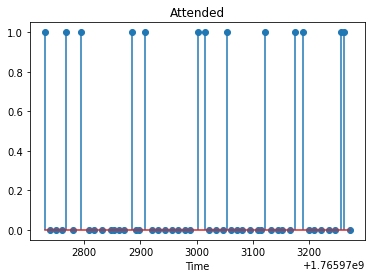

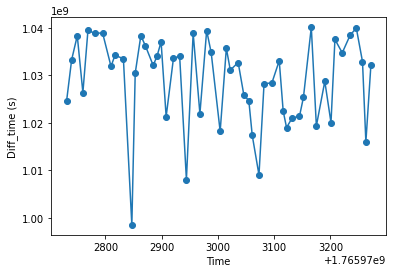

Errores de comisión: 0
Errores de omision: 13
Tiempos de reacción:  []
0


In [56]:
import numpy as np
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import matplotlib.pyplot as plt


def  encuentra_impulsos(df_a,df_t,busca=0):
    #Poner busca 1 para buscar atendidos y 0 para los no atendidos
    pos = np.where(df_a['data']==busca)
    #print(pos)
    t =  np.array(df_a['log_time_s'])
    t = t[pos]
    #print( t )
    #print( np.array(df_a['data']))

    tiempos = []
    for tt in t:
        indice = np.abs(np.array(df_t['log_time_s']) - tt).argmin()
     #   print(indice)
        tiempos = np.append(tiempos, np.array(df_t['data'])[indice])

    return (tiempos)

root = tk.Tk()
root.withdraw()

'''file_path = filedialog.askopenfilename(
    title="Selecciona el CSV",
    filetypes=[("CSV files", "*.csv")]
)

if file_path:
    df = pd.read_csv(file_path)
    df.head()
    print(df.head)
else:
    print("No se seleccionó ningún archivo")
'''  
    
folder_path = filedialog.askdirectory(title="Selecciona la carpeta raíz para buscar MCAPs")
if folder_path:
    file_a = folder_path +'/Attended.csv'
    file_t = folder_path + '/diff_time.csv'
    df_a = pd.read_csv(file_a, 
                        quotechar ='"')
    df_t = pd.read_csv(file_t)
    print(df_a.head())
    print(df_t.head())
    random_time = np.diff(df_a['log_time_s'])-0.5  #No quitar 0.5, que sirve para compensar el retardo de publicación
    plt.stem(df_a['log_time_s'],df_a['data'])
    plt.title('Attended')
    plt.xlabel('Time')
    plt.show()
    plt.plot(df_t['log_time_s'],df_t['data'],'-o')
    plt.ylabel('Diff_time (s)')
    plt.xlabel('Time')
    plt.show()

    
    tr_at=encuentra_impulsos(df_a,df_t,1)

    tr_nat= encuentra_impulsos(df_a,df_t,0)

    ErroresComision = np.sum(tr_nat<3)
    ErroresOmision = np.sum(tr_at>3)
    tr = tr_nat[np.where(tr_at<3)]

    print(f"Errores de comisión: {ErroresComision}" )
    print(f"Errores de omision: {ErroresOmision}"   )
    print(f"Tiempos de reacción:  {tr}" )
    print(np.sum(tr_nat<3))

    
else:
    print("No se seleccionó ningún archivo")
    


In [18]:
# La diferencia entre los instantes en los que se ha generado un tono, es el tiempo que está publicado en el 
# hilo random_time.csv. Sin embargo, como la publicación del dato se hace mediante un timer que se ejecuta cada 0.5s, 
# hay que compensarlo. Por tanto, para obtener ese valor lo podemos estimar de la siguiente forma:

print(np.diff(df_a['log_time_s'])-0.5)


[10.56663942  5.22796798  7.58000636  9.27860785  9.77375865 12.09321308
  7.97175407  7.22784042 12.63066554 13.13207364  8.25720859  5.46340609
 12.51869369  9.1426816  11.41463566 10.82904553 11.66700172  7.39859986
 10.80671406 13.85729241 12.89189744 10.21064353 11.07040024 11.44135213
 14.01197338 14.49732876]


Errores de comisión: 16
Errores de omision: 0
Tiempos de reacción:  [0.07448554 0.10680485 0.09122038 0.04110336 0.08729148 0.06399965
 0.08244824 0.04536629 0.12117124 0.05666685 0.05027795]
16


In [35]:
a=np.zeros(2)
print(a)
a = np.append(a,2)
print(a)

[0. 0.]
[0. 0. 2.]
